In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from scipy import stats

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


<h2>Project Paths</h2>

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

<h2>Load Cleaned Dataset</h2>

In [3]:
DATA_PATH = (
    PROCESSED_DATA_DIR /
    "online_retail_cleaned.csv"
)

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["InvoiceDate"]
)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

Rows: 1,010,535
Columns: 24


<h2>Load Returns</h2>

In [4]:
RETURNS_PATH = (
    PROCESSED_DATA_DIR /
    "online_retail_returns.csv"
)

returns_df = pd.read_csv(
    RETURNS_PATH,
    parse_dates=["InvoiceDate"]
)

print(f"Return rows: {len(returns_df):,}")

Return rows: 22,496


<h2>Initial Overview</h2>

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,IsZeroPrice,DescriptionClean,Year,Month,MonthName,Quarter,Day,DayOfWeek,DayName,Hour,IsWeekend,YearMonth,TotalPrice,PriceOutlier_IQR,PriceOutlier_ZScore
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,Sale,False,15CM CHRISTMAS GLASS BALL 20 LIGHTS,2009,12,December,4,1,1,Tuesday,7,False,2009-12,83.40,False,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,Sale,False,PINK CHERRY LIGHTS,2009,12,December,4,1,1,Tuesday,7,False,2009-12,81.00,False,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,Sale,False,WHITE CHERRY LIGHTS,2009,12,December,4,1,1,Tuesday,7,False,2009-12,81.00,False,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,Sale,False,"RECORD FRAME 7"" SINGLE SIZE",2009,12,December,4,1,1,Tuesday,7,False,2009-12,100.80,False,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,Sale,False,STRAWBERRY CERAMIC TRINKET BOX,2009,12,December,4,1,1,Tuesday,7,False,2009-12,30.00,False,False


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1010535 entries, 0 to 1010534
Data columns (total 24 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   Invoice              1010535 non-null  object        
 1   StockCode            1010535 non-null  str           
 2   Description          1008893 non-null  str           
 3   Quantity             1010535 non-null  int64         
 4   InvoiceDate          1010535 non-null  datetime64[us]
 5   UnitPrice            1010535 non-null  float64       
 6   CustomerID           779495 non-null   float64       
 7   Country              1010535 non-null  str           
 8   TransactionType      1010535 non-null  str           
 9   IsZeroPrice          1010535 non-null  bool          
 10  DescriptionClean     1008893 non-null  str           
 11  Year                 1010535 non-null  int64         
 12  Month                1010535 non-null  int64         
 13  MonthNam

In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Year,Month,Quarter,Day,DayOfWeek,Hour,TotalPrice
count,"1,010,535.00",1010535,"1,010,535.00","779,495.00","1,010,535.00","1,010,535.00","1,010,535.00","1,010,535.00","1,010,535.00","1,010,535.00","1,010,535.00"
mean,11.34,2011-01-04 07:06:30.117531,4.06,"15,320.26","2,010.44",7.40,2.79,15.35,2.46,13.02,20.26
min,1.00,2009-12-01 07:45:00,0.00,"12,346.00","2,009.00",1.00,1.00,1.00,0.00,6.00,0.00
25%,1.00,2010-07-06 09:51:00,1.25,"13,971.00","2,010.00",4.00,2.00,8.00,1.00,11.00,4.13
50%,4.00,2010-12-09 14:27:00,2.10,"15,246.00","2,010.00",8.00,3.00,15.00,2.00,13.00,10.08
75%,12.00,2011-07-28 10:33:00,4.13,"16,794.00","2,011.00",11.00,4.00,23.00,4.00,15.00,17.70
max,"80,995.00",2011-12-09 12:50:00,"25,111.09","18,287.00","2,011.00",12.00,4.00,31.00,6.00,20.00,"168,469.60"
std,131.47,NaN,50.37,"1,695.72",0.58,3.50,1.14,8.64,1.88,2.43,205.45


<h2>Core Business Metrics</h2>

In [8]:
total_revenue = df["TotalPrice"].sum()

total_units = df["Quantity"].sum()

total_orders = df["Invoice"].nunique()

total_products = df["StockCode"].nunique()

total_customers = df["CustomerID"].nunique()

total_countries = df["Country"].nunique()

average_order_value = (
    df.groupby("Invoice")["TotalPrice"]
    .sum()
    .mean()
)

print(f"Revenue:          £{total_revenue:,.2f}")
print(f"Units sold:       {total_units:,.0f}")
print(f"Orders:           {total_orders:,}")
print(f"Products:         {total_products:,}")
print(f"Customers:        {total_customers:,}")
print(f"Countries:        {total_countries:,}")
print(f"Average order:    £{average_order_value:,.2f}")

Revenue:          £20,476,634.02
Units sold:       11,455,908
Orders:           41,942
Products:         4,984
Customers:        5,881
Countries:        43
Average order:    £488.21


<h2>Create an Order-Level Dataset</h2>

In [9]:
order_df = (
    df.groupby("Invoice")
    .agg(
        OrderValue=("TotalPrice", "sum"),
        TotalUnits=("Quantity", "sum"),
        UniqueProducts=("StockCode", "nunique"),
        CustomerID=("CustomerID", "first"),
        Country=("Country", "first"),
        InvoiceDate=("InvoiceDate", "first")
    )
    .reset_index()
)

order_df.head()

,Invoice,OrderValue,TotalUnits,UniqueProducts,CustomerID,Country,InvoiceDate
0,489434,505.30,166,8,"13,085.00",United Kingdom,2009-12-01 07:45:00
1,489435,145.80,60,4,"13,085.00",United Kingdom,2009-12-01 07:46:00
2,489436,630.33,193,19,"13,078.00",United Kingdom,2009-12-01 09:06:00
3,489437,310.75,145,23,"15,362.00",United Kingdom,2009-12-01 09:08:00
4,489438,"2,286.24",826,17,"18,102.00",United Kingdom,2009-12-01 09:24:00


In [10]:
order_df = (
    df.groupby("Invoice")
    .agg(
        OrderValue=("TotalPrice", "sum"),
        TotalUnits=("Quantity", "sum"),
        UniqueProducts=("StockCode", "nunique"),
        CustomerID=("CustomerID", "first"),
        Country=("Country", "first"),
        InvoiceDate=("InvoiceDate", "first")
    )
    .reset_index()
)

order_df.head()

,Invoice,OrderValue,TotalUnits,UniqueProducts,CustomerID,Country,InvoiceDate
0,489434,505.30,166,8,"13,085.00",United Kingdom,2009-12-01 07:45:00
1,489435,145.80,60,4,"13,085.00",United Kingdom,2009-12-01 07:46:00
2,489436,630.33,193,19,"13,078.00",United Kingdom,2009-12-01 09:06:00
3,489437,310.75,145,23,"15,362.00",United Kingdom,2009-12-01 09:08:00
4,489438,"2,286.24",826,17,"18,102.00",United Kingdom,2009-12-01 09:24:00


<h2>Order Value Distribution</h2>

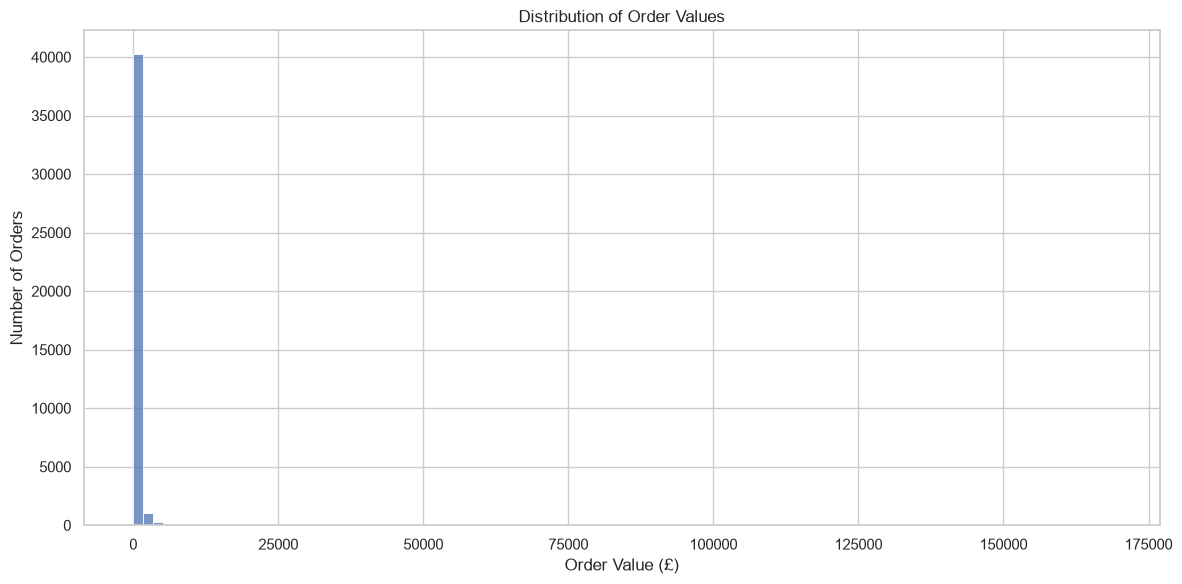

In [11]:
plt.figure(figsize=(12, 6))

sns.histplot(
    order_df["OrderValue"],
    bins=100
)

plt.title("Distribution of Order Values")
plt.xlabel("Order Value (£)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

<h2>Order Value — Remove Extreme Display Values</h2>

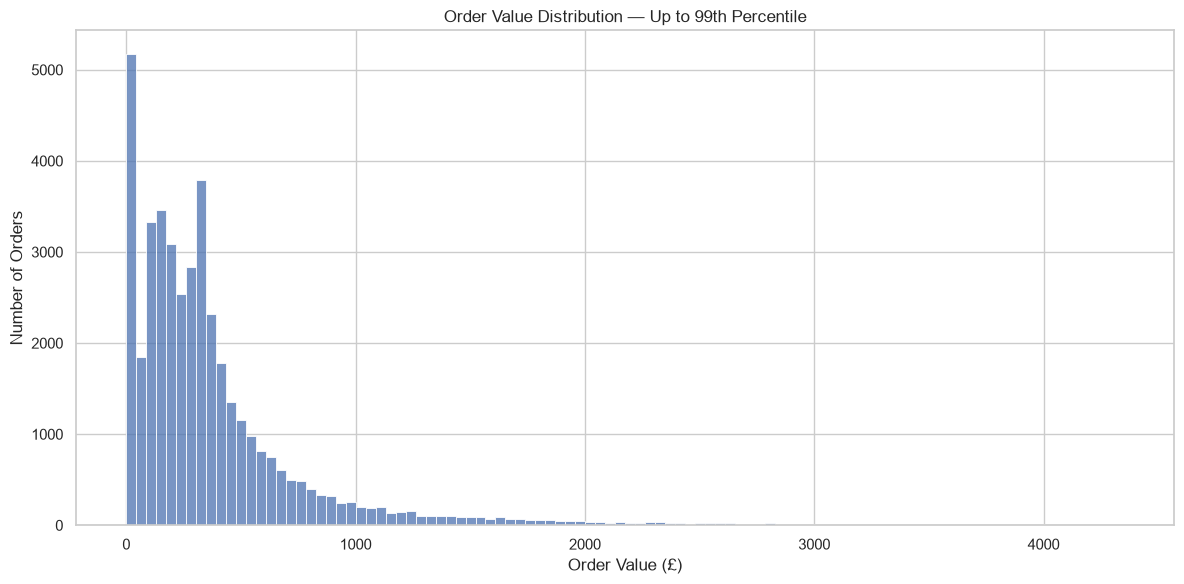

In [12]:
order_value_99 = order_df["OrderValue"].quantile(0.99)

plt.figure(figsize=(12, 6))

sns.histplot(
    order_df.loc[
        order_df["OrderValue"] <= order_value_99,
        "OrderValue"
    ],
    bins=100
)

plt.title("Order Value Distribution — Up to 99th Percentile")
plt.xlabel("Order Value (£)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

<h2>Boxplot of Order Values</h2>

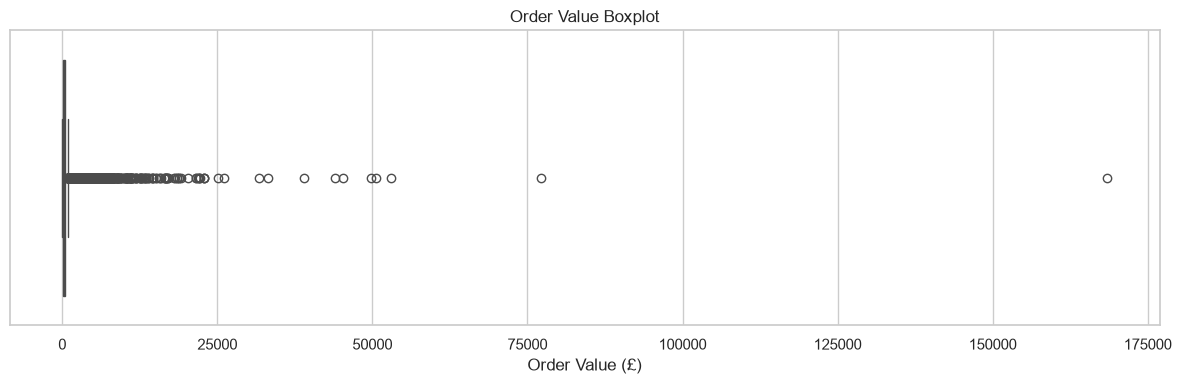

In [13]:
plt.figure(figsize=(12, 4))

sns.boxplot(
    x=order_df["OrderValue"]
)

plt.title("Order Value Boxplot")
plt.xlabel("Order Value (£)")

plt.tight_layout()
plt.show()

<h2>Quantity Distribution</h2>

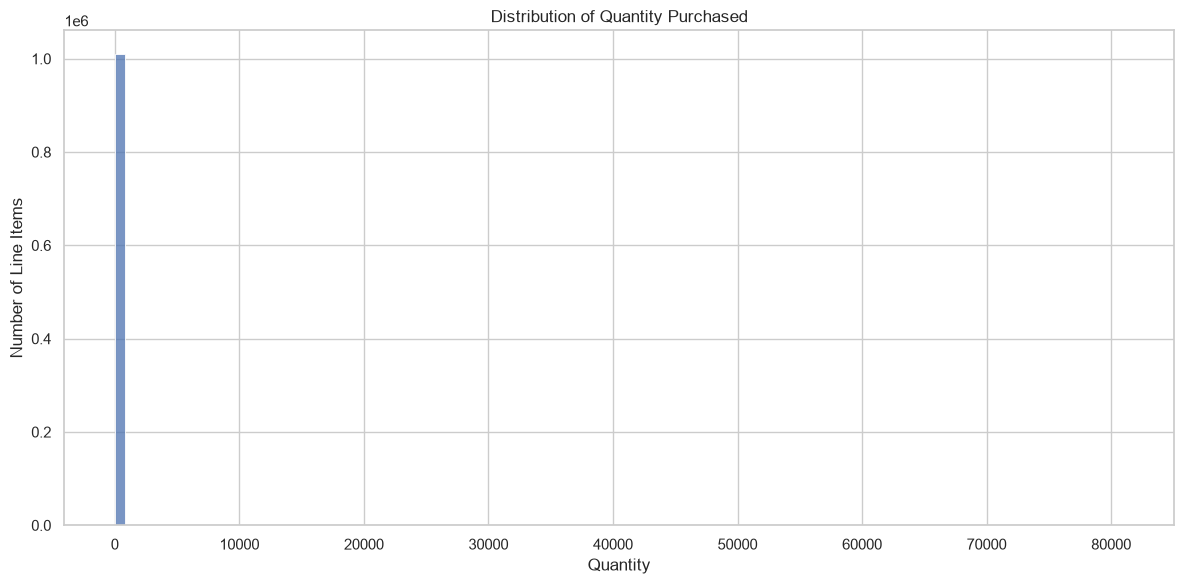

In [14]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["Quantity"],
    bins=100
)

plt.title("Distribution of Quantity Purchased")
plt.xlabel("Quantity")
plt.ylabel("Number of Line Items")

plt.tight_layout()
plt.show()

<h2>Quantity Distribution — 99th Percentile</h2>

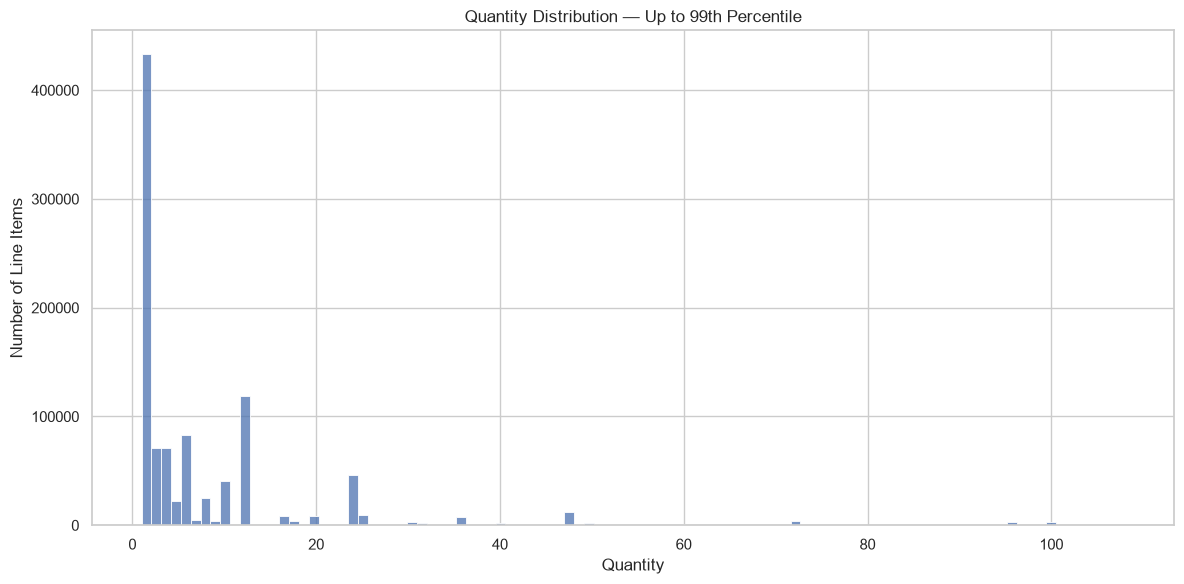

In [15]:
quantity_99 = df["Quantity"].quantile(0.99)

plt.figure(figsize=(12, 6))

sns.histplot(
    df.loc[
        df["Quantity"] <= quantity_99,
        "Quantity"
    ],
    bins=100
)

plt.title("Quantity Distribution — Up to 99th Percentile")
plt.xlabel("Quantity")
plt.ylabel("Number of Line Items")

plt.tight_layout()
plt.show()

<h2>Unit Price Distribution</h2>

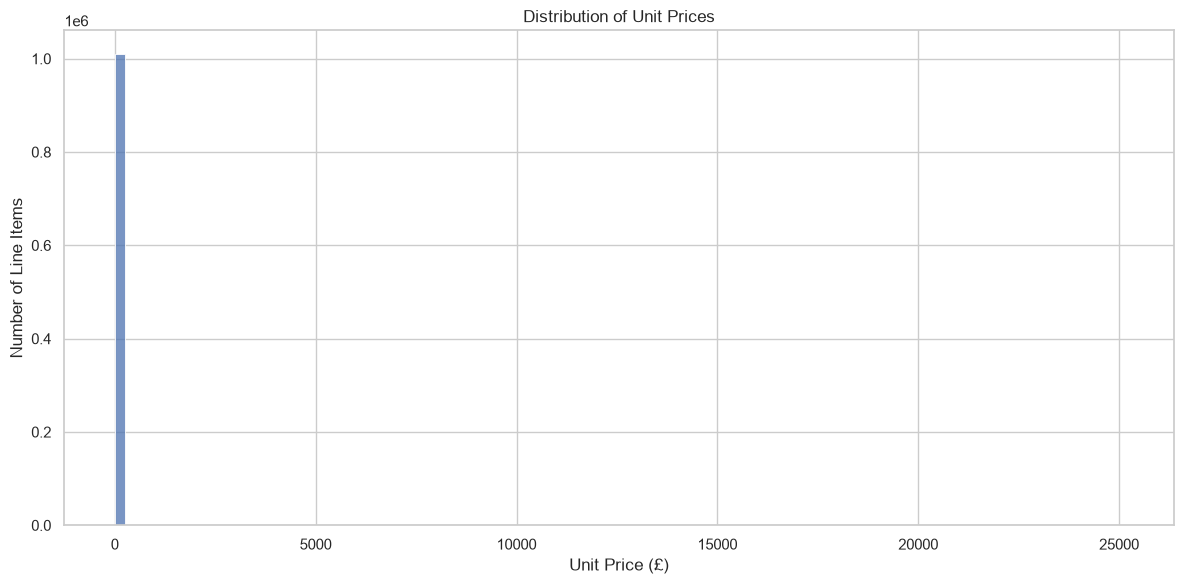

In [16]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["UnitPrice"],
    bins=100
)

plt.title("Distribution of Unit Prices")
plt.xlabel("Unit Price (£)")
plt.ylabel("Number of Line Items")

plt.tight_layout()
plt.show()

<h2>Unit Price — Log Scale</h2>

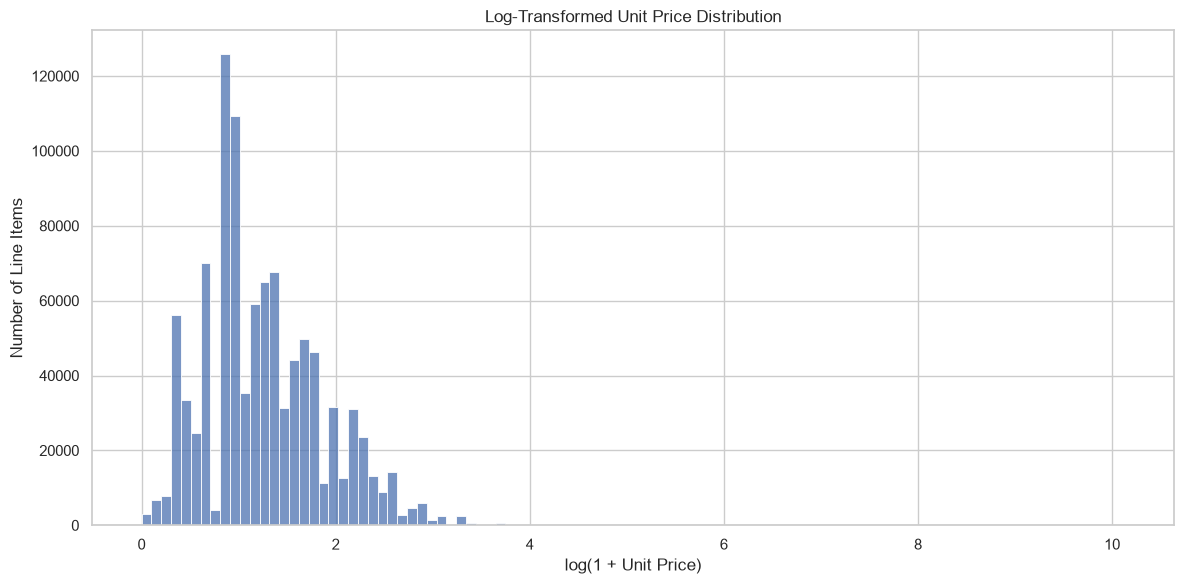

In [17]:
plt.figure(figsize=(12, 6))

sns.histplot(
    np.log1p(df["UnitPrice"]),
    bins=100
)

plt.title("Log-Transformed Unit Price Distribution")
plt.xlabel("log(1 + Unit Price)")
plt.ylabel("Number of Line Items")

plt.tight_layout()
plt.show()

<h2>Unit Price Boxplot</h2>

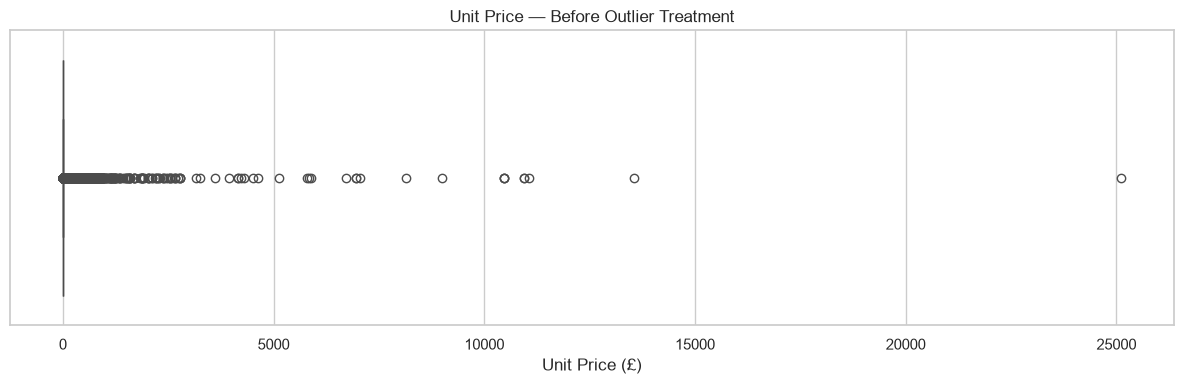

In [18]:
plt.figure(figsize=(12, 4))

sns.boxplot(
    x=df["UnitPrice"]
)

plt.title("Unit Price — Before Outlier Treatment")
plt.xlabel("Unit Price (£)")

plt.tight_layout()
plt.show()

<h2>Compare IQR and Z-Score Outliers</h2>

In [19]:
outlier_summary = pd.DataFrame({
    "Method": [
        "IQR",
        "Z-Score"
    ],
    "Outliers": [
        df["PriceOutlier_IQR"].sum(),
        df["PriceOutlier_ZScore"].sum()
    ]
})

outlier_summary

,Method,Outliers
0,IQR,63132
1,Z-Score,492


In [20]:
outlier_summary["Percentage"] = (
    outlier_summary["Outliers"] /
    len(df) *
    100
)

outlier_summary

,Method,Outliers,Percentage
0,IQR,63132,6.25
1,Z-Score,492,0.05


<h2>Visualize Outlier Comparison</h2>

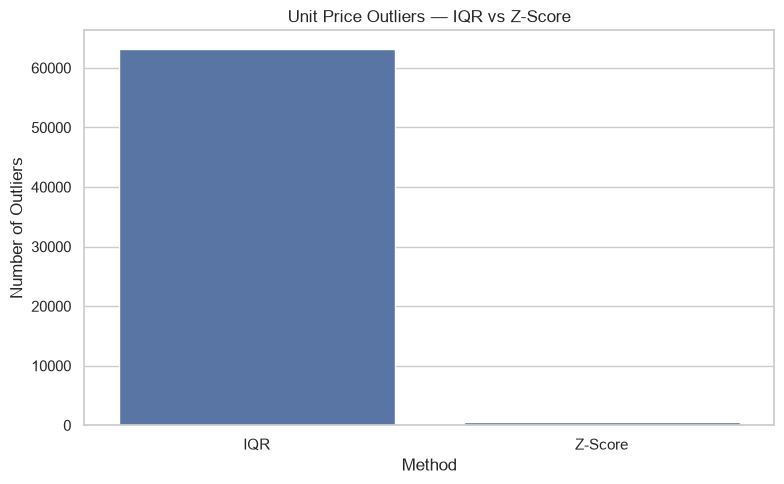

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=outlier_summary,
    x="Method",
    y="Outliers"
)

plt.title("Unit Price Outliers — IQR vs Z-Score")
plt.ylabel("Number of Outliers")

plt.tight_layout()
plt.show()

<h2>Create an Outlier-Treated Dataset</h2>

In [22]:
df_no_price_outliers = df[
    ~df["PriceOutlier_IQR"]
].copy()

print(
    f"Original rows: "
    f"{len(df):,}"
)

print(
    f"After removing IQR price outliers: "
    f"{len(df_no_price_outliers):,}"
)

Original rows: 1,010,535
After removing IQR price outliers: 947,403


<h2>Compare Revenue Before/After Outlier Treatment</h2>

In [23]:
revenue_before = df["TotalPrice"].sum()

revenue_after = (
    df_no_price_outliers["TotalPrice"]
    .sum()
)

revenue_difference = (
    revenue_before - revenue_after
)

print(f"Revenue before: £{revenue_before:,.2f}")
print(f"Revenue after:  £{revenue_after:,.2f}")
print(f"Difference:     £{revenue_difference:,.2f}")

Revenue before: £20,476,634.02
Revenue after:  £17,588,749.96
Difference:     £2,887,884.06


<h2>Price Distribution After IQR Filtering</h2>

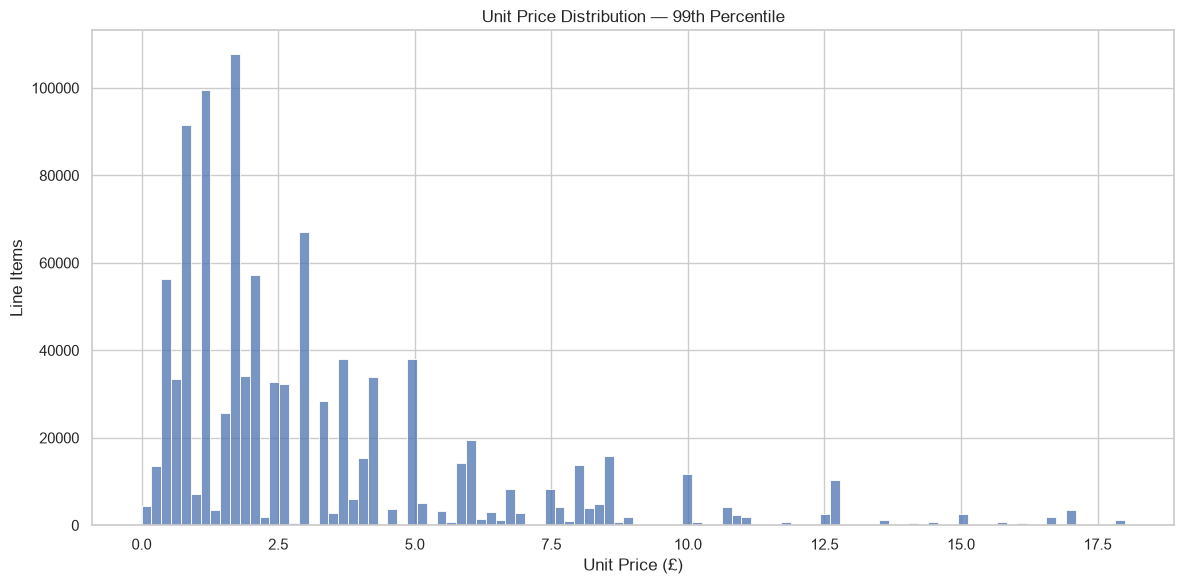

In [24]:
price_99 = df["UnitPrice"].quantile(0.99)

plt.figure(figsize=(12, 6))

sns.histplot(
    df.loc[
        df["UnitPrice"] <= price_99,
        "UnitPrice"
    ],
    bins=100
)

plt.title(
    "Unit Price Distribution — "
    "99th Percentile"
)

plt.xlabel("Unit Price (£)")
plt.ylabel("Line Items")

plt.tight_layout()
plt.show()

<h2>Price vs Quantity</h2>

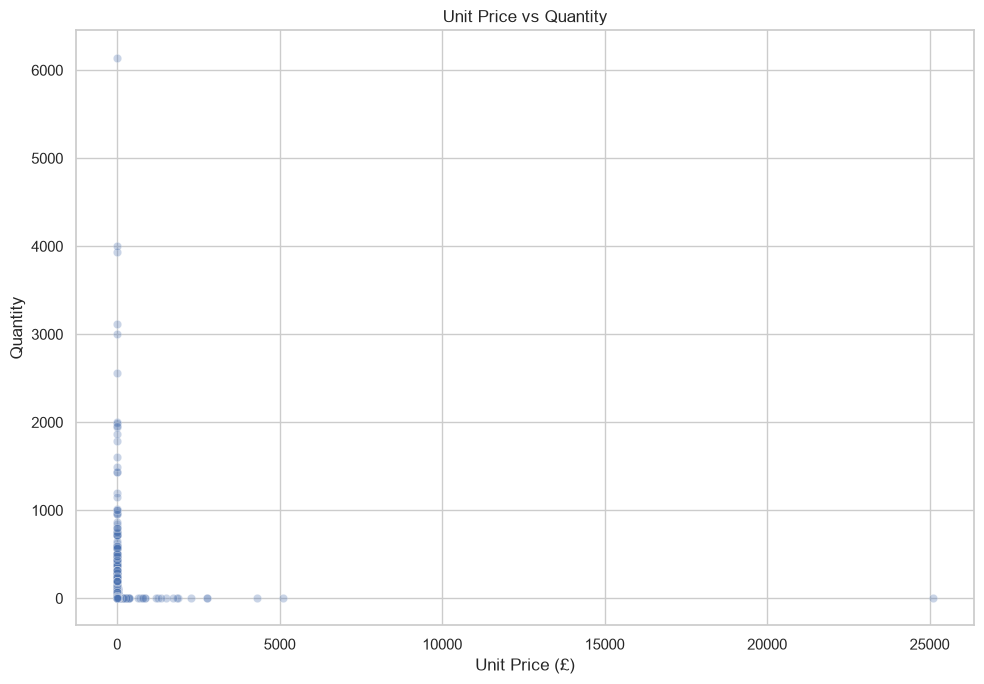

In [25]:
sample_df = df.sample(
    min(50_000, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=sample_df,
    x="UnitPrice",
    y="Quantity",
    alpha=0.3
)

plt.title("Unit Price vs Quantity")
plt.xlabel("Unit Price (£)")
plt.ylabel("Quantity")

plt.tight_layout()
plt.show()

<h2>Price vs Quantity — Log Scale</h2>

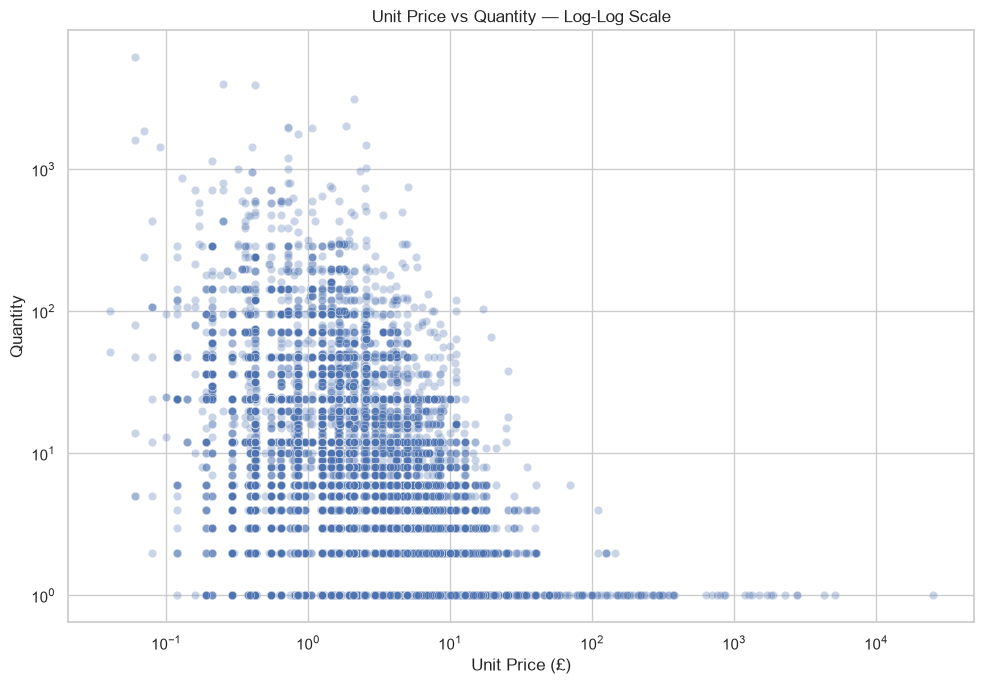

In [26]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=sample_df[
        (sample_df["UnitPrice"] > 0) &
        (sample_df["Quantity"] > 0)
    ],
    x="UnitPrice",
    y="Quantity",
    alpha=0.3
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Unit Price vs Quantity — Log-Log Scale"
)

plt.xlabel("Unit Price (£)")
plt.ylabel("Quantity")

plt.tight_layout()
plt.show()

<h2>Correlation</h2>

In [27]:
pearson_corr = df[
    ["UnitPrice", "Quantity"]
].corr(
    method="pearson"
)

pearson_corr

,UnitPrice,Quantity
UnitPrice,1.00,-0.00
Quantity,-0.00,1.00


In [28]:
spearman_corr = df[
    ["UnitPrice", "Quantity"]
].corr(
    method="spearman"
)

spearman_corr

,UnitPrice,Quantity
UnitPrice,1.00,-0.43
Quantity,-0.43,1.00


<h2>Revenue by Country</h2>

In [29]:
country_revenue = (
    df.groupby("Country")
    .agg(
        Revenue=("TotalPrice", "sum"),
        Units=("Quantity", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("CustomerID", "nunique")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)

country_revenue.head(20)

,Revenue,Units,Orders,Customers
Country,,,,
United Kingdom,"17,410,569.69",9437245,38399,5353
EIRE,"658,767.31",336604,626,5
Netherlands,"554,038.09",384519,229,22
Germany,"425,019.71",225173,789,107
France,"350,456.09",271902,622,95
Australia,"169,283.46",104067,95,15
Spain,"108,332.49",50318,154,41
Switzerland,"100,685.59",52763,93,22
Sweden,"91,869.82",88633,105,19


<h2>Top 15 Countries by Revenue</h2>

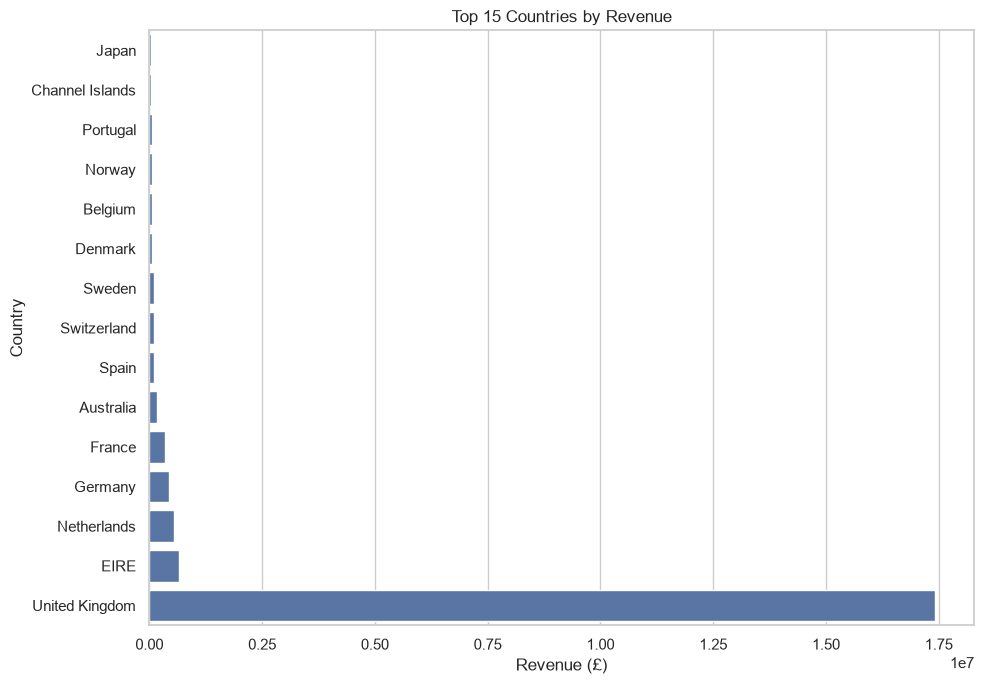

In [30]:
top_countries = (
    country_revenue
    .head(15)
    .sort_values("Revenue")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_countries.reset_index(),
    x="Revenue",
    y="Country"
)

plt.title("Top 15 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

<h2>Top Countries by Volume</h2>

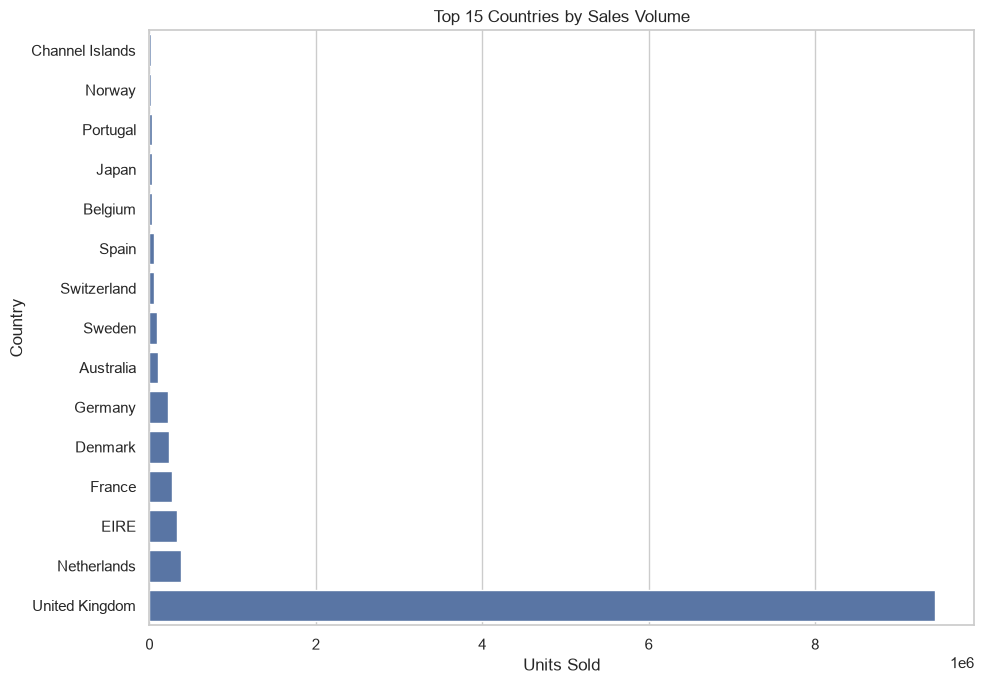

In [31]:
top_volume_countries = (
    country_revenue
    .sort_values(
        "Units",
        ascending=False
    )
    .head(15)
    .sort_values("Units")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_volume_countries.reset_index(),
    x="Units",
    y="Country"
)

plt.title("Top 15 Countries by Sales Volume")
plt.xlabel("Units Sold")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

<h2>Average Order Value by Country</h2>

In [32]:
country_aov = (
    order_df.groupby("Country")
    .agg(
        Orders=("Invoice", "nunique"),
        Revenue=("OrderValue", "sum")
    )
)

country_aov["AOV"] = (
    country_aov["Revenue"] /
    country_aov["Orders"]
)

country_aov = (
    country_aov
    .sort_values("AOV", ascending=False)
)

country_aov.head(20)

,Orders,Revenue,AOV
Country,,,
Netherlands,229,"554,038.09","2,419.38"
Singapore,11,"25,317.06","2,301.55"
Australia,95,"169,283.46","1,781.93"
Denmark,43,"68,580.69","1,594.90"
Hong Kong,15,"23,685.52","1,579.03"
Thailand,2,"3,070.54","1,535.27"
Japan,33,"43,023.91","1,303.75"
Bermuda,1,"1,253.14","1,253.14"
Norway,45,"56,322.50","1,251.61"


In [33]:
country_aov_reliable = country_aov[
    country_aov["Orders"] >= 50
]

country_aov_reliable.head(20)

,Orders,Revenue,AOV
Country,,,
Netherlands,229,"554,038.09","2,419.38"
Australia,95,"169,283.46","1,781.93"
Switzerland,93,"100,685.59","1,082.64"
EIRE,626,"658,767.31","1,052.34"
Sweden,105,"91,869.82",874.95
Channel Islands,55,"44,623.33",811.33
Spain,154,"108,332.49",703.46
Portugal,95,"56,283.53",592.46
France,622,"350,456.09",563.43


<h2>Monthly Revenue</h2>

In [34]:
monthly_revenue = (
    df.groupby("YearMonth")
    .agg(
        Revenue=("TotalPrice", "sum"),
        Units=("Quantity", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("CustomerID", "nunique")
    )
)

monthly_revenue

,Revenue,Units,Orders,Customers
YearMonth,,,,
2009-12,"822,483.95",444341,1839,955
2010-01,"651,155.11",395234,1206,720
2010-02,"551,878.30",391861,1283,774
2010-03,"830,915.26",530314,1770,1057
2010-04,"678,875.25",385747,1512,942
2010-05,"657,705.50",424009,1642,966
2010-06,"749,537.31",413723,1719,1041
2010-07,"648,810.27",358590,1584,928
2010-08,"695,251.91",521762,1511,911


<h2>Revenue Trend</h2>

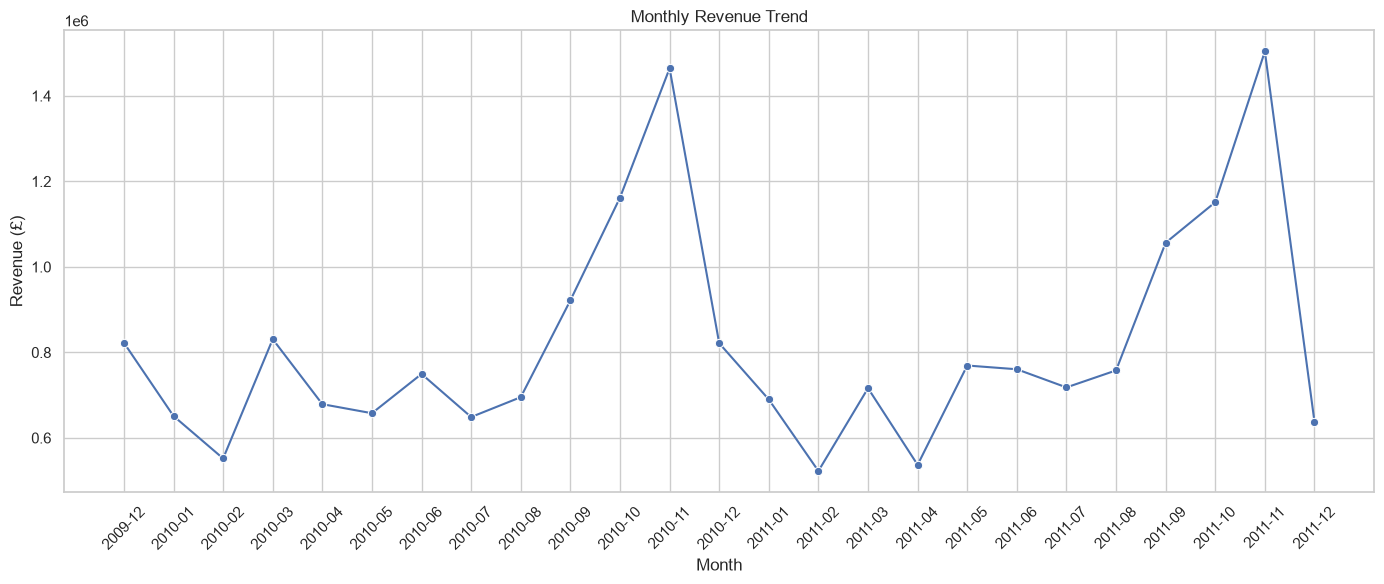

In [35]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_revenue,
    x=monthly_revenue.index.astype(str),
    y="Revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<h2>Monthly Orders</h2>

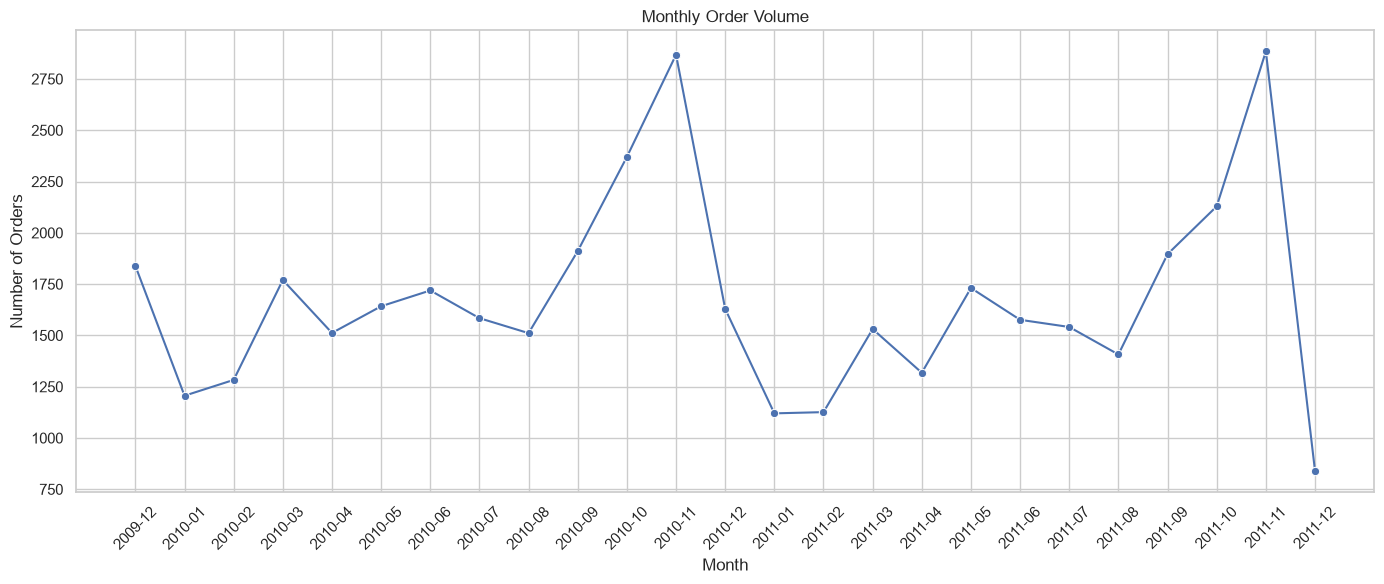

In [36]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_revenue,
    x=monthly_revenue.index.astype(str),
    y="Orders",
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<h2>Monthly Average Order Value</h2>

In [37]:
monthly_revenue["AOV"] = (
    monthly_revenue["Revenue"] /
    monthly_revenue["Orders"]
)

monthly_revenue

,Revenue,Units,Orders,Customers,AOV
YearMonth,,,,,
2009-12,"822,483.95",444341,1839,955,447.25
2010-01,"651,155.11",395234,1206,720,539.93
2010-02,"551,878.30",391861,1283,774,430.15
2010-03,"830,915.26",530314,1770,1057,469.44
2010-04,"678,875.25",385747,1512,942,448.99
2010-05,"657,705.50",424009,1642,966,400.55
2010-06,"749,537.31",413723,1719,1041,436.03
2010-07,"648,810.27",358590,1584,928,409.60
2010-08,"695,251.91",521762,1511,911,460.13


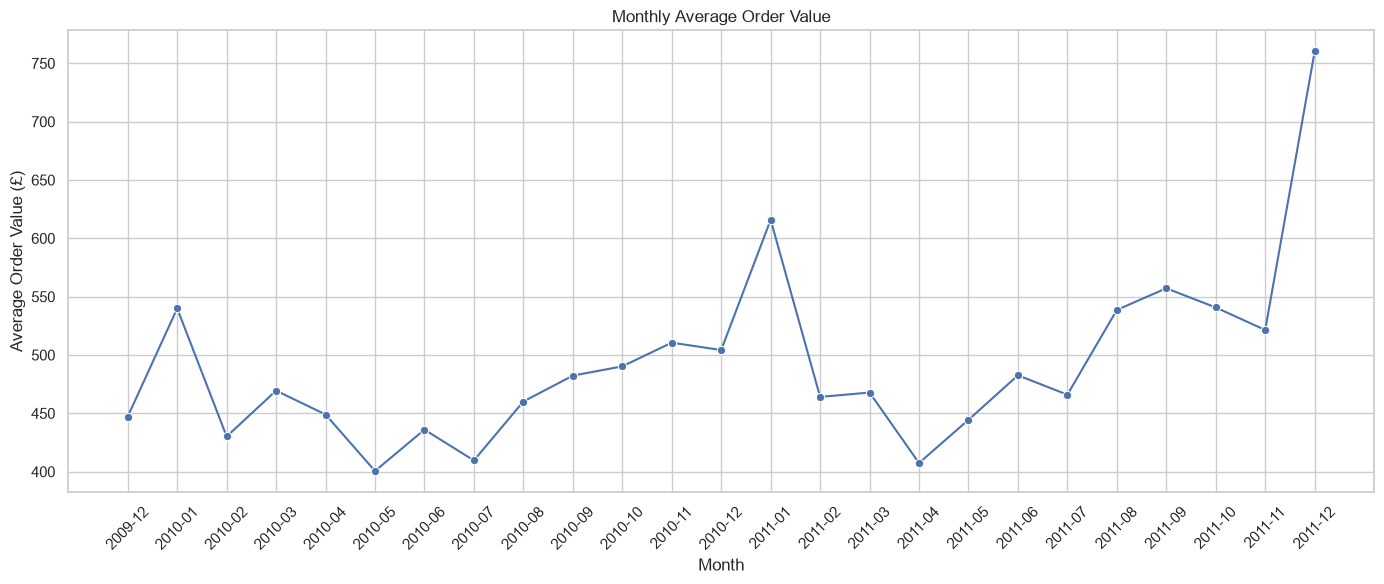

In [38]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_revenue,
    x=monthly_revenue.index.astype(str),
    y="AOV",
    marker="o"
)

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value (£)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<h2>Monthly Average Order Value</h2>

In [39]:
monthly_revenue["AOV"] = (
    monthly_revenue["Revenue"] /
    monthly_revenue["Orders"]
)

monthly_revenue

,Revenue,Units,Orders,Customers,AOV
YearMonth,,,,,
2009-12,"822,483.95",444341,1839,955,447.25
2010-01,"651,155.11",395234,1206,720,539.93
2010-02,"551,878.30",391861,1283,774,430.15
2010-03,"830,915.26",530314,1770,1057,469.44
2010-04,"678,875.25",385747,1512,942,448.99
2010-05,"657,705.50",424009,1642,966,400.55
2010-06,"749,537.31",413723,1719,1041,436.03
2010-07,"648,810.27",358590,1584,928,409.60
2010-08,"695,251.91",521762,1511,911,460.13


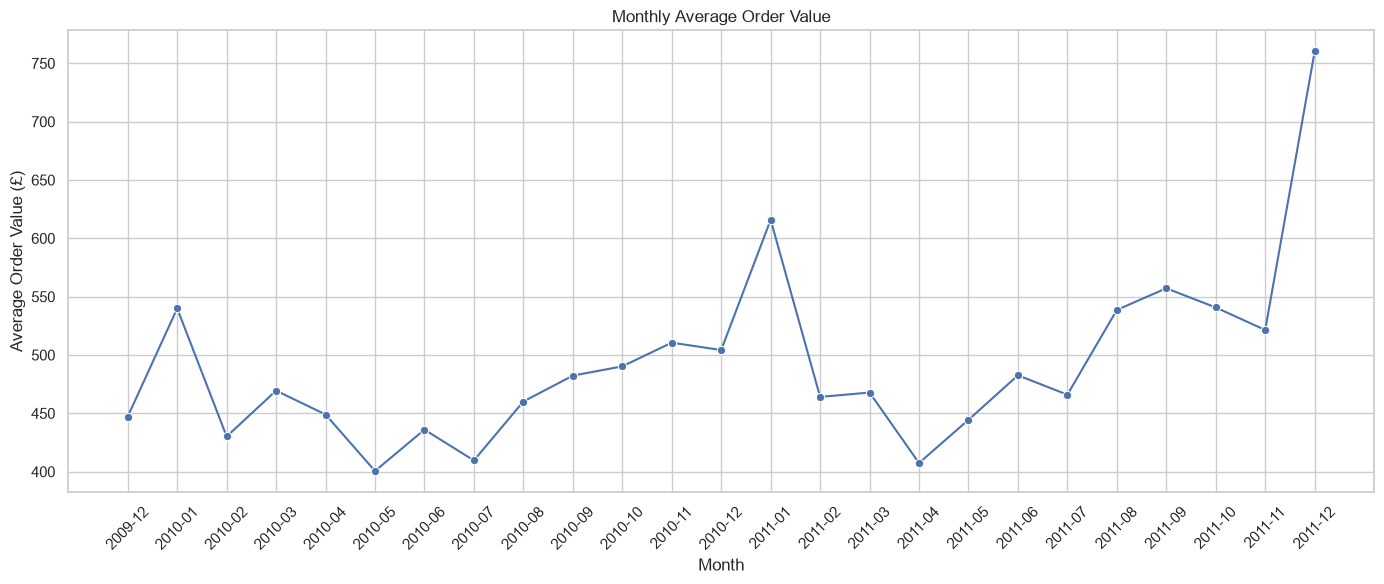

In [40]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_revenue,
    x=monthly_revenue.index.astype(str),
    y="AOV",
    marker="o"
)

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value (£)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<h2>Revenue by Day of Week</h2>

In [41]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_revenue = (
    df.groupby("DayName")["TotalPrice"]
    .sum()
    .reindex(day_order)
)

day_revenue

DayName
Monday      3,581,967.75
Tuesday     4,078,149.96
Wednesday   3,488,444.33
Thursday    4,195,212.76
Friday      3,323,908.88
Saturday        9,803.05
Sunday      1,799,147.28
Name: TotalPrice, dtype: float64

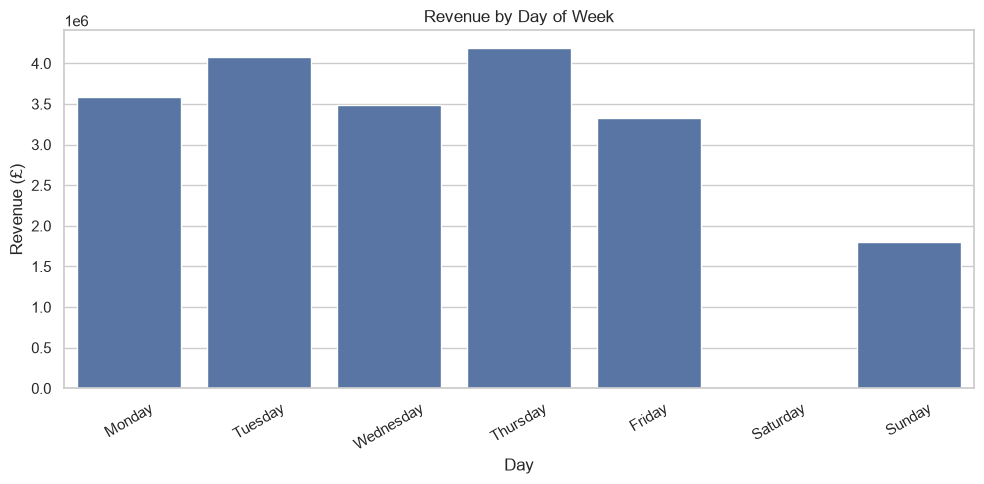

In [42]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_revenue.index,
    y=day_revenue.values
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

<h2>Orders by Day of Week</h2>

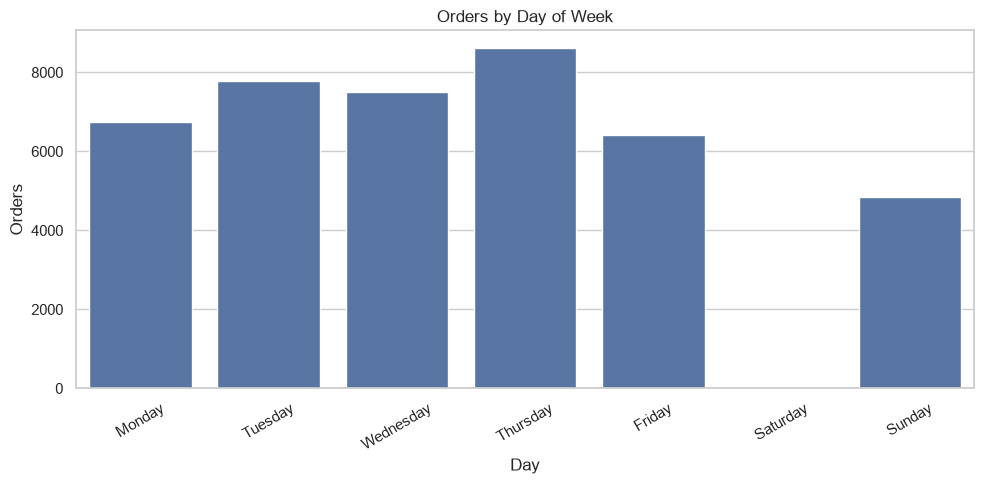

In [43]:
day_orders = (
    df.groupby("DayName")["Invoice"]
    .nunique()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_orders.index,
    y=day_orders.values
)

plt.title("Orders by Day of Week")
plt.xlabel("Day")
plt.ylabel("Orders")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

<h2>Revenue by Hour</h2>

In [44]:
hourly_revenue = (
    df.groupby("Hour")["TotalPrice"]
    .sum()
)

hourly_revenue

Hour
6            4.25
7       75,765.57
8      528,559.14
9    1,769,631.03
10   2,581,131.33
11   2,535,325.46
12   2,850,377.67
13   2,548,467.54
14   2,321,684.73
15   2,394,943.79
16   1,570,143.80
17     861,460.13
18     273,405.02
19     126,830.35
20      38,904.19
Name: TotalPrice, dtype: float64

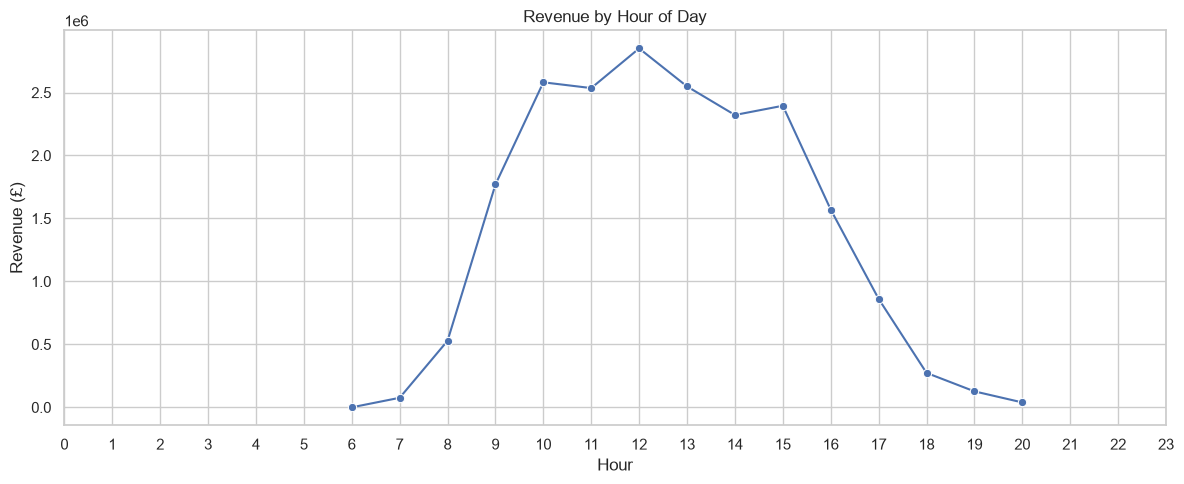

In [45]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    x=hourly_revenue.index,
    y=hourly_revenue.values,
    marker="o"
)

plt.title("Revenue by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Revenue (£)")

plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

<h2>Orders by Hour</h2>

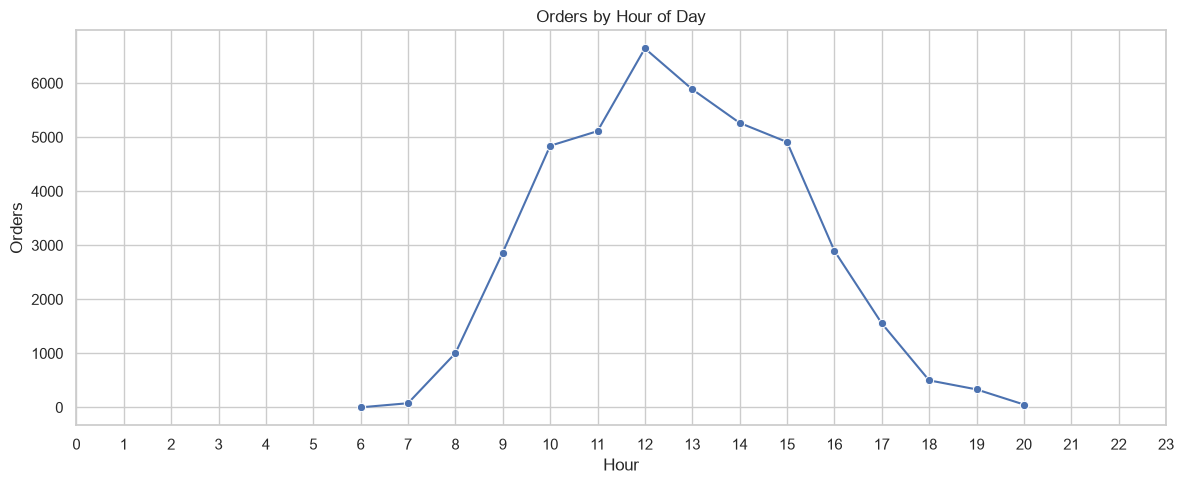

In [46]:
hourly_orders = (
    df.groupby("Hour")["Invoice"]
    .nunique()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=hourly_orders.index,
    y=hourly_orders.values,
    marker="o"
)

plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Orders")

plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

<h2>Heatmap — Day × Hour</h2>

In [47]:
day_hour = (
    df.pivot_table(
        index="DayName",
        columns="Hour",
        values="TotalPrice",
        aggfunc="sum"
    )
)

day_hour = day_hour.reindex(day_order)

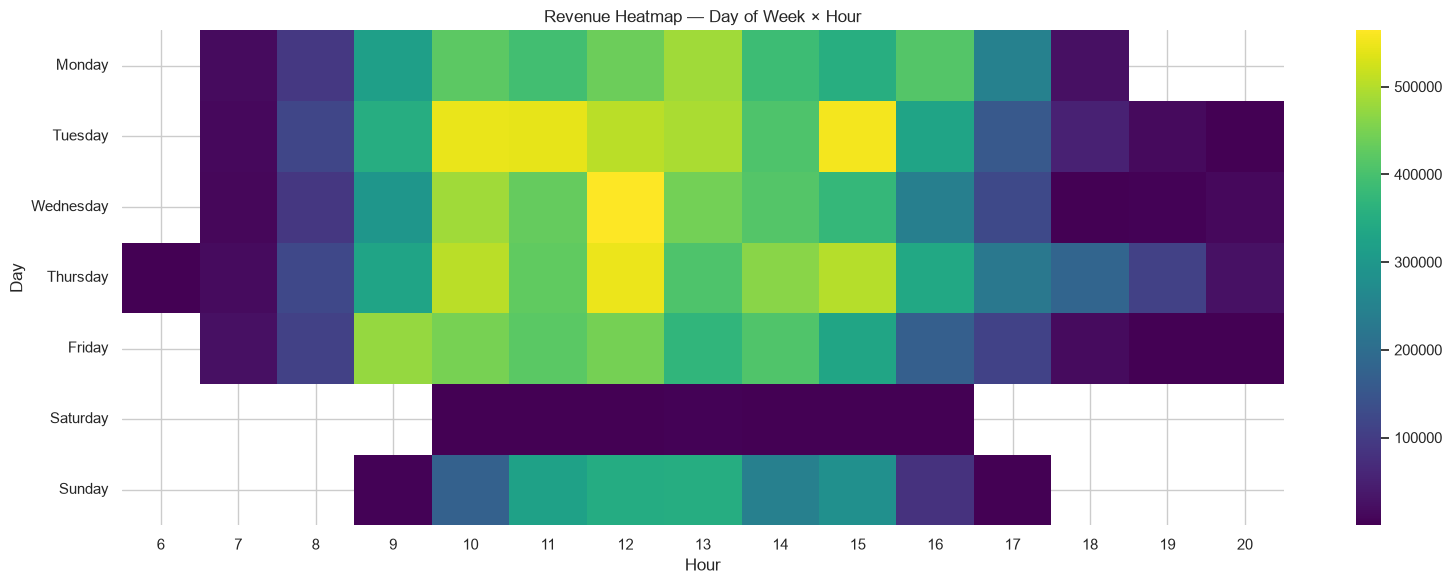

In [48]:
plt.figure(figsize=(16, 6))

sns.heatmap(
    day_hour,
    cmap="viridis"
)

plt.title("Revenue Heatmap — Day of Week × Hour")
plt.xlabel("Hour")
plt.ylabel("Day")

plt.tight_layout()
plt.show()

<h2>Missingness Analysis</h2>

In [49]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": df.isna().mean() * 100
})

missing_summary.sort_values(
    "Missing %",
    ascending=False
)

,Missing Count,Missing %
CustomerID,231040,22.86
Description,1642,0.16
DescriptionClean,1642,0.16
Invoice,0,0.00
Quarter,0,0.00
PriceOutlier_IQR,0,0.00
TotalPrice,0,0.00
YearMonth,0,0.00
IsWeekend,0,0.00
Hour,0,0.00


<h2>Missingness Visualization</h2>

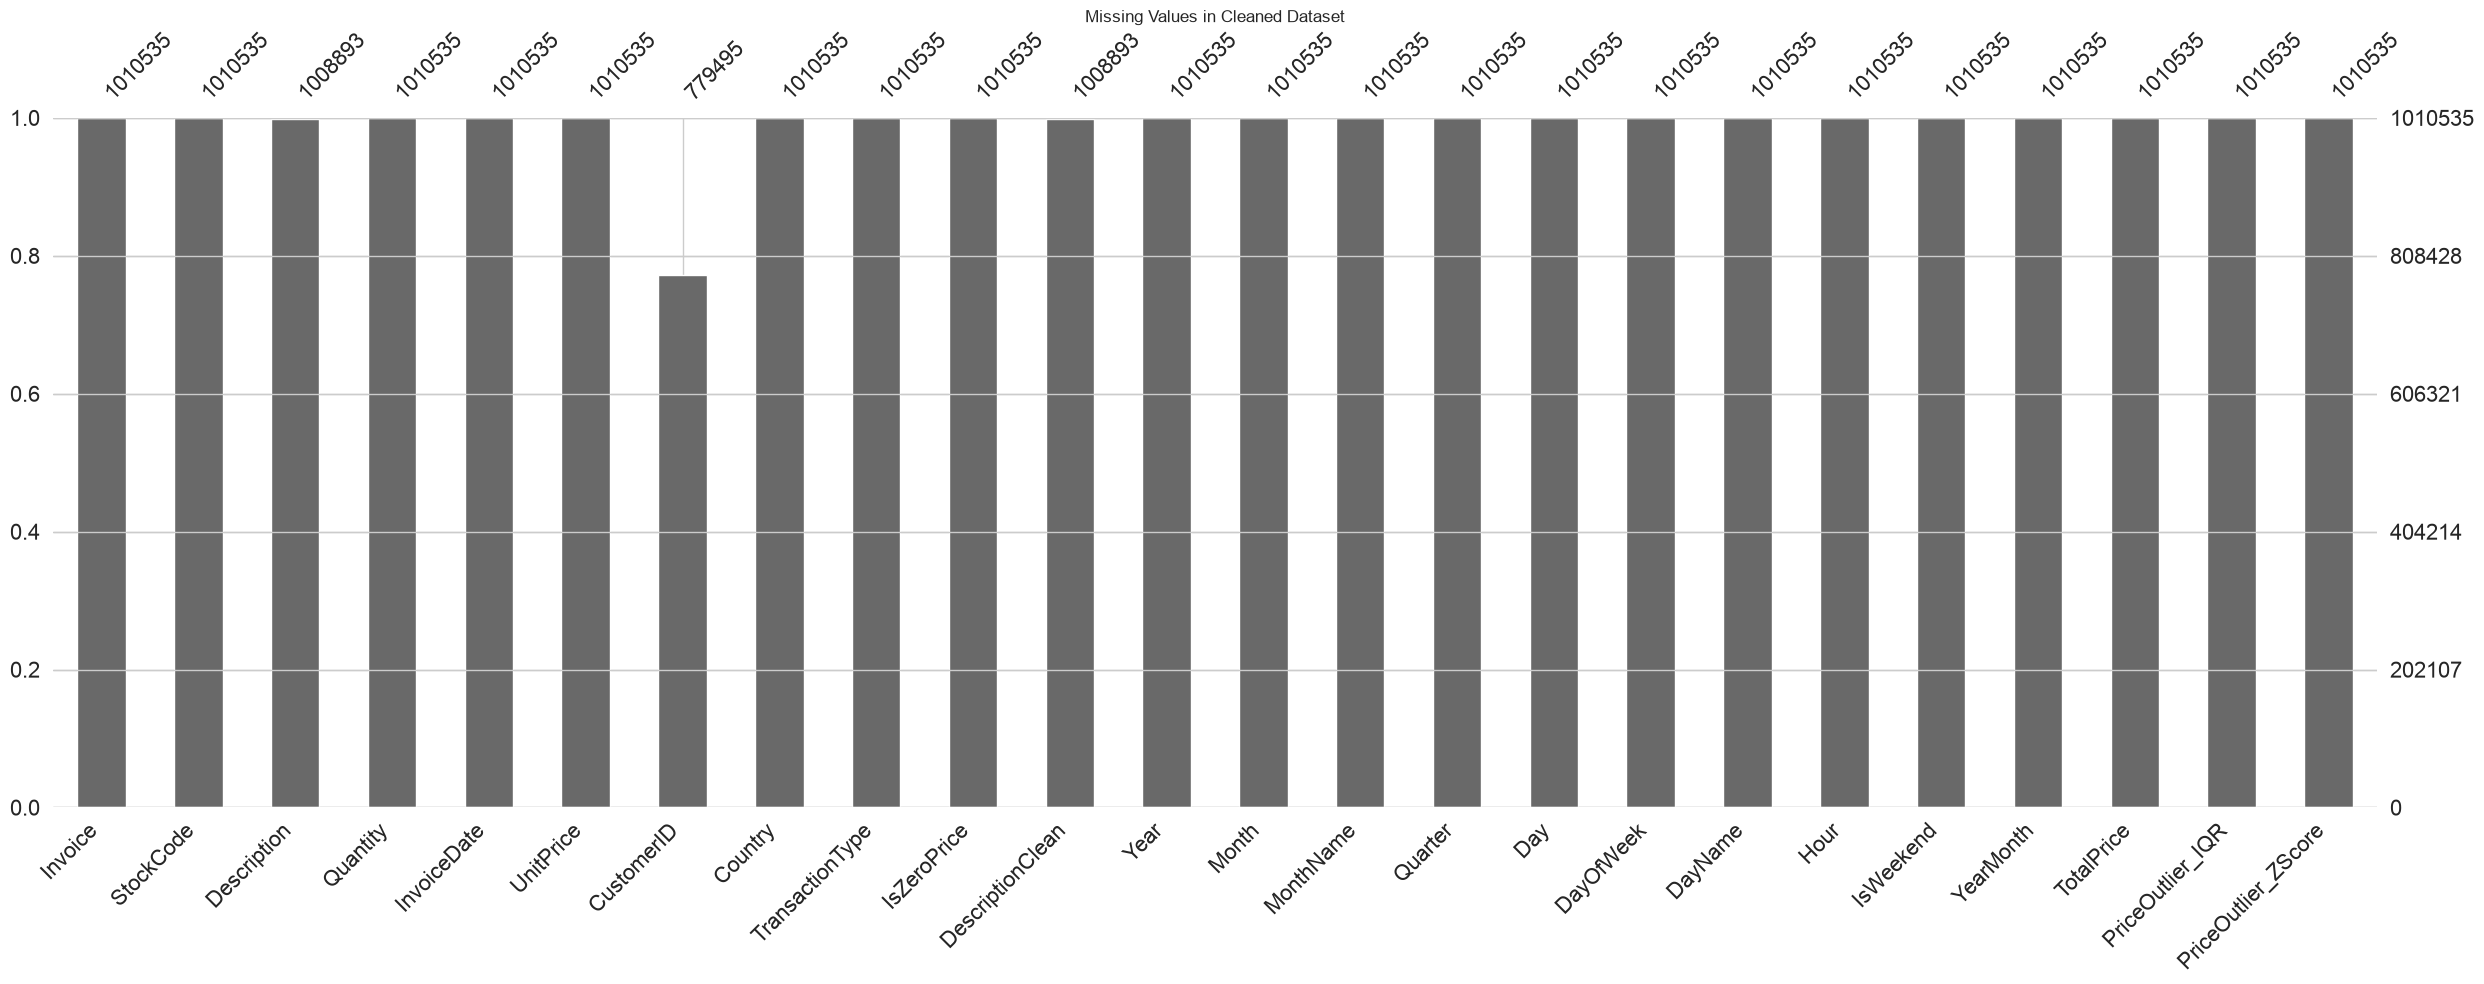

In [50]:
msno.bar(df)

plt.title("Missing Values in Cleaned Dataset")

plt.tight_layout()
plt.show()

<h2>CustomerID Missingness by Country</h2>

In [51]:
customer_missing_by_country = (
    df.assign(
        CustomerMissing=df["CustomerID"].isna()
    )
    .groupby("Country")["CustomerMissing"]
    .mean()
    .mul(100)
    .sort_values(
        ascending=False
    )
)

customer_missing_by_country.head(20)

Country
Hong Kong              100.00
Bermuda                100.00
Bahrain                 52.42
Unspecified             30.75
RSA                     26.79
United Kingdom          24.57
Lebanon                 21.05
United Arab Emirates    17.99
Israel                  12.84
EIRE                     9.28
Portugal                 4.62
Switzerland              3.75
Sweden                   1.42
France                   0.94
Norway                   0.00
Poland                   0.00
Nigeria                  0.00
Australia                0.00
Spain                    0.00
Saudi Arabia             0.00
Name: CustomerMissing, dtype: float64

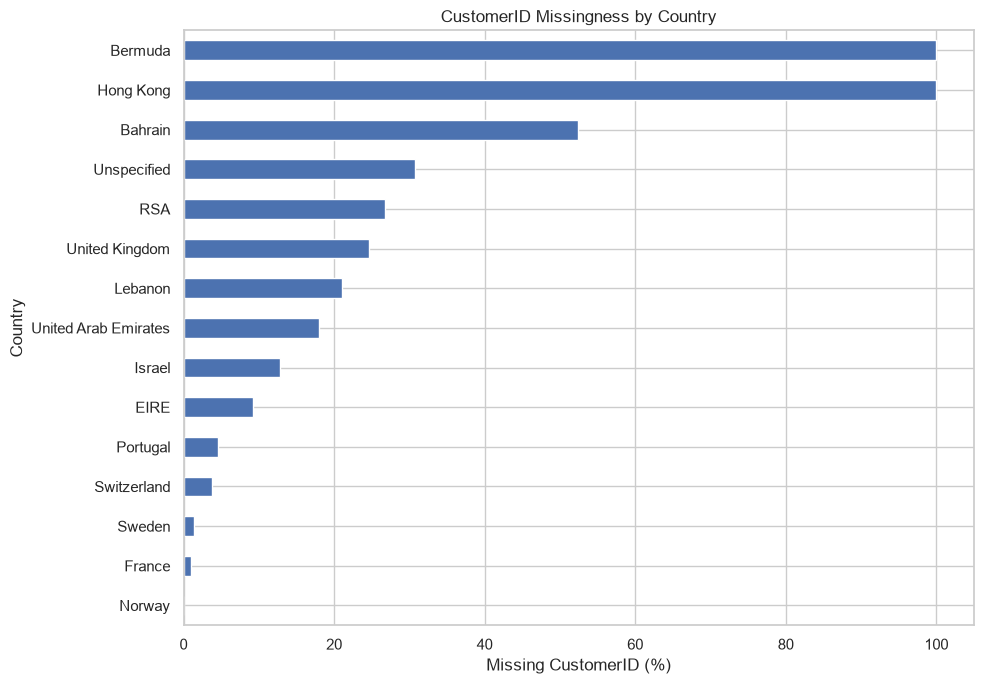

In [52]:
plt.figure(figsize=(10, 7))

customer_missing_by_country.head(15).sort_values().plot(
    kind="barh"
)

plt.title(
    "CustomerID Missingness by Country"
)

plt.xlabel("Missing CustomerID (%)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

<h2>Correlation Matrix</h2>

In [53]:
numeric_features = [
    "Quantity",
    "UnitPrice",
    "TotalPrice",
    "Year",
    "Month",
    "DayOfWeek",
    "Hour"
]

correlation_matrix = (
    df[numeric_features]
    .corr()
)

correlation_matrix

,Quantity,UnitPrice,TotalPrice,Year,Month,DayOfWeek,Hour
Quantity,1.00,-0.00,0.79,-0.00,-0.01,-0.01,-0.02
UnitPrice,-0.00,1.00,0.25,-0.00,-0.00,-0.01,0.00
TotalPrice,0.79,0.25,1.00,0.00,-0.00,-0.01,-0.02
Year,-0.00,-0.00,0.00,1.00,-0.15,-0.01,0.00
Month,-0.01,-0.00,-0.00,-0.15,1.00,0.02,0.03
DayOfWeek,-0.01,-0.01,-0.01,-0.01,0.02,1.00,-0.02
Hour,-0.02,0.00,-0.02,0.00,0.03,-0.02,1.00


<h2>Correlation Heatmap</h2>

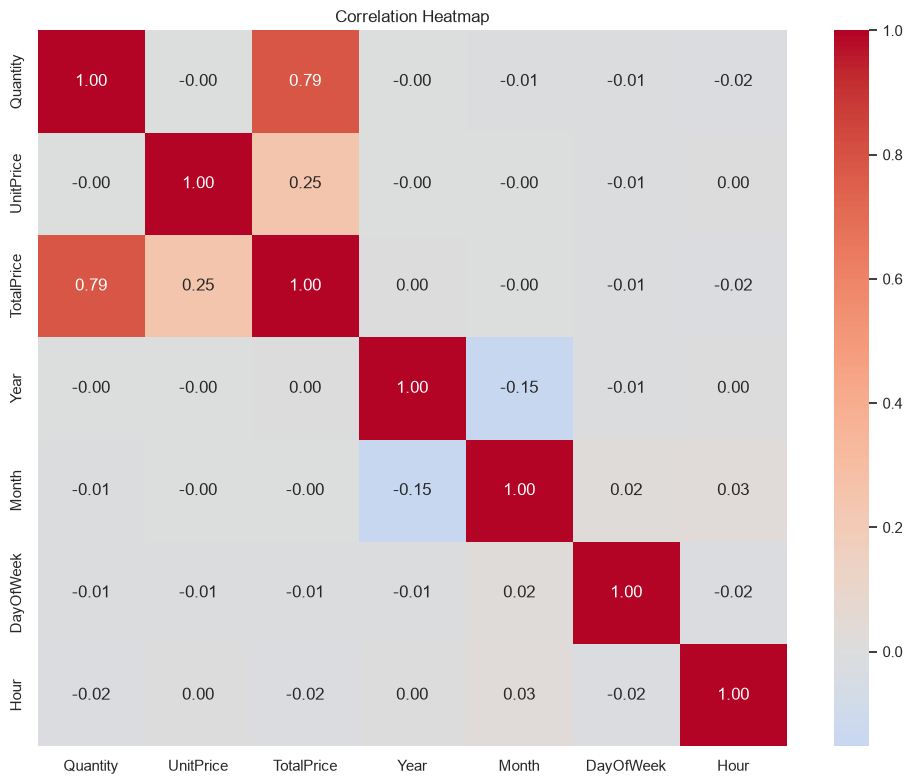

In [54]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

<h2>Top Products by Revenue</h2>

In [55]:
product_revenue = (
    df.groupby(
        [
            "StockCode",
            "DescriptionClean"
        ]
    )
    .agg(
        Revenue=("TotalPrice", "sum"),
        Units=("Quantity", "sum"),
        Orders=("Invoice", "nunique")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)

product_revenue.head(20)

,,Revenue,Units,Orders
StockCode,DescriptionClean,,,
M,MANUAL,"339,599.81",9637,791
22423,REGENCY CAKESTAND 3 TIER,"330,590.32",26495,3920
DOT,DOTCOM POSTAGE,"309,854.11",1420,1420
85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,546.20",94147,5361
23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1
47566,PARTY BUNTING,"148,318.28",28217,2676
85099B,JUMBO BAG RED RETROSPOT,"145,961.83",77286,3249
84879,ASSORTED COLOUR BIRD ORNAMENT,"129,324.49",80090,2808
POST,POSTAGE,"125,682.42",5363,1851


<h2>Top 20 Products by Revenue</h2>

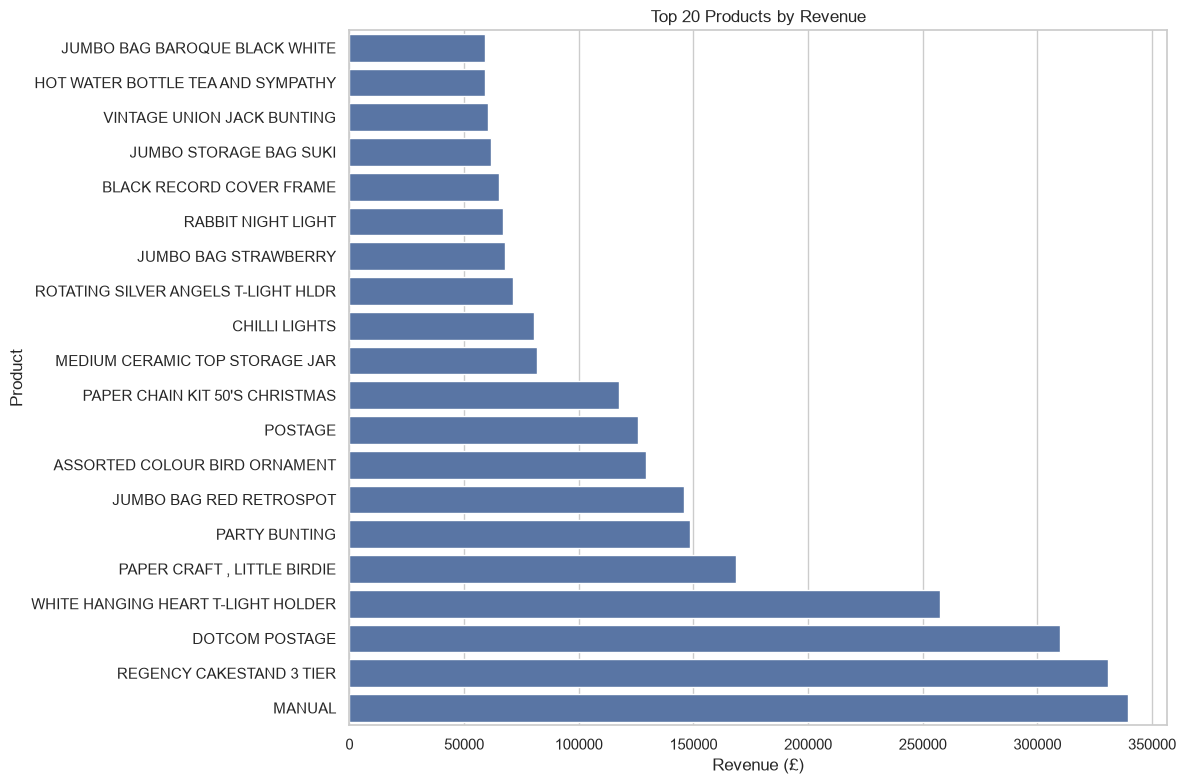

In [56]:
top_products = (
    product_revenue
    .head(20)
    .sort_values("Revenue")
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_products.reset_index(),
    x="Revenue",
    y="DescriptionClean"
)

plt.title("Top 20 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

<h2>Top Products by Volume</h2>

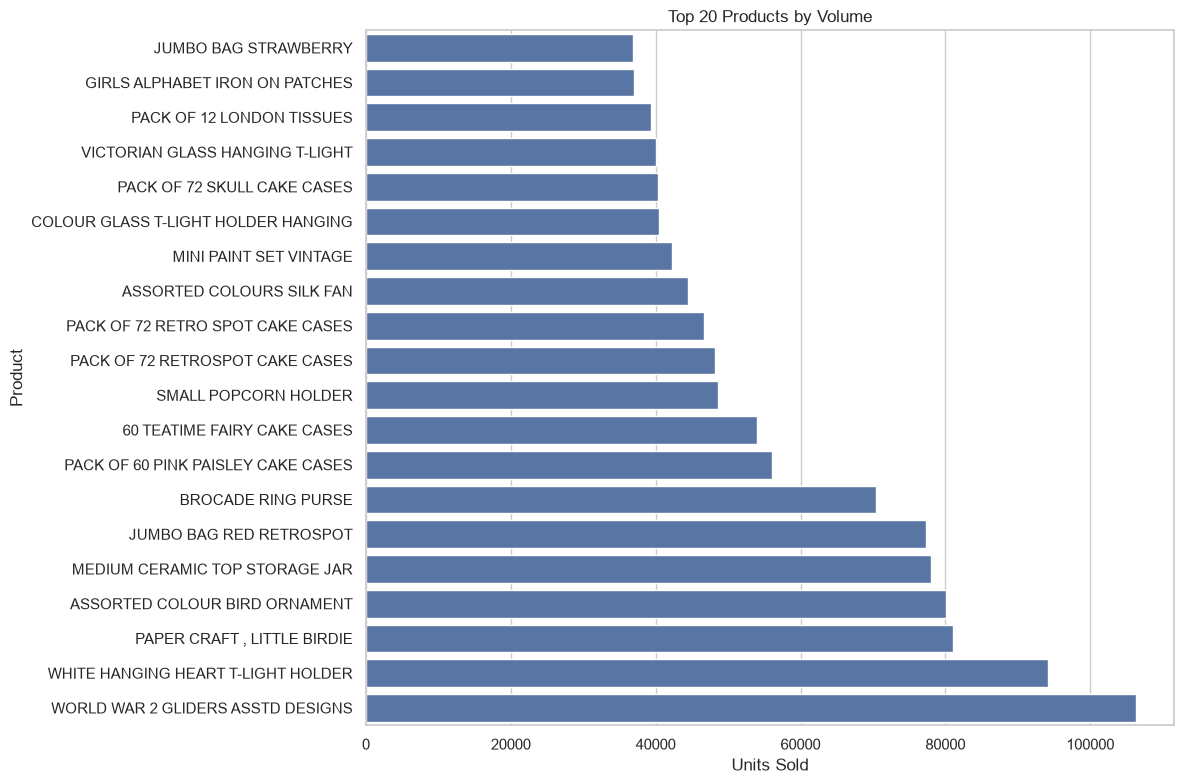

In [57]:
top_volume_products = (
    product_revenue
    .sort_values(
        "Units",
        ascending=False
    )
    .head(20)
    .sort_values("Units")
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_volume_products.reset_index(),
    x="Units",
    y="DescriptionClean"
)

plt.title("Top 20 Products by Volume")
plt.xlabel("Units Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

<h2>Returns Analysis</h2>

In [58]:
returns_summary = {
    "Return Transactions": len(returns_df),
    "Returned Units": returns_df["Quantity"].abs().sum(),
    "Return Value": returns_df["ReturnValue"].sum(),
    "Unique Return Invoices": returns_df["Invoice"].nunique(),
    "Customers with Returns": returns_df["CustomerID"].nunique()
}

pd.Series(returns_summary)

Return Transactions         22,496.00
Returned Units           1,046,134.00
Return Value             1,462,424.18
Unique Return Invoices      11,684.00
Customers with Returns       2,572.00
dtype: float64

<h2>Monthly Returns</h2>

In [59]:
monthly_returns = (
    returns_df
    .assign(
        YearMonth=returns_df["InvoiceDate"].dt.to_period("M")
    )
    .groupby("YearMonth")
    .agg(
        ReturnValue=("ReturnValue", "sum"),
        ReturnedUnits=("Quantity", lambda x: x.abs().sum()),
        ReturnTransactions=("Invoice", "nunique")
    )
)

monthly_returns

,ReturnValue,ReturnedUnits,ReturnTransactions
YearMonth,,,
2009-12,"25,835.45",25771,491
2010-01,"28,675.61",20724,428
2010-02,"20,612.93",24360,687
2010-03,"67,668.02",42302,597
2010-04,"37,354.20",35270,379
2010-05,"44,434.78",61238,776
2010-06,"72,463.44",27276,497
2010-07,"31,444.79",57415,432
2010-08,"40,477.52",70987,366


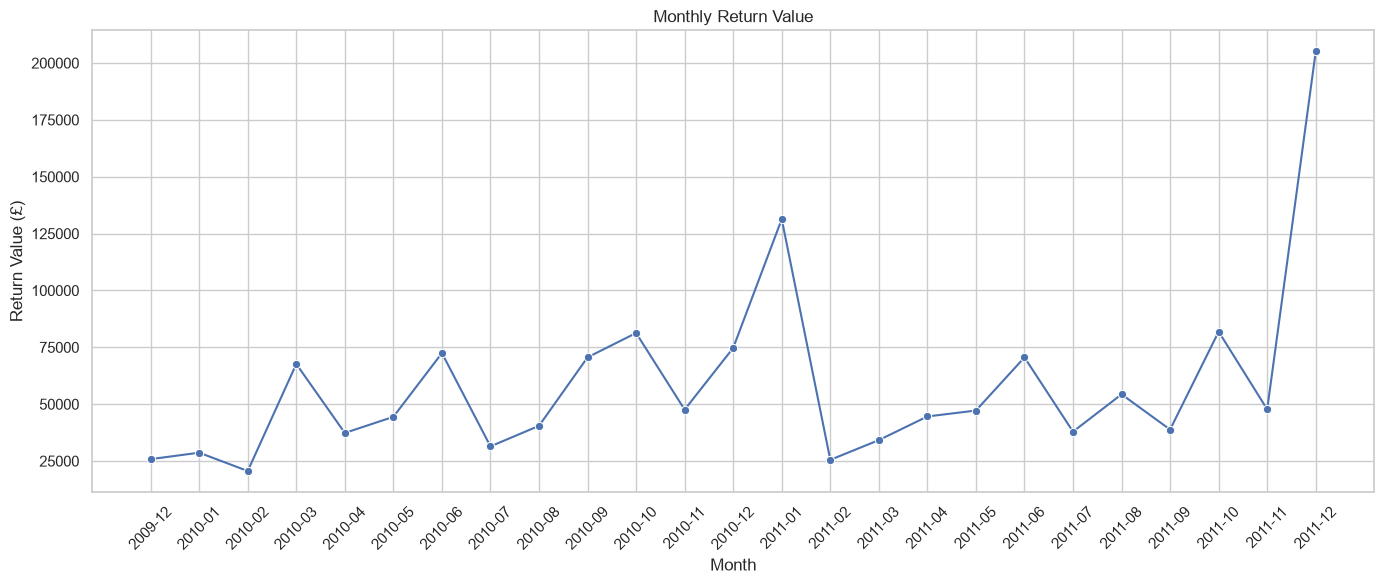

In [60]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_returns,
    x=monthly_returns.index.astype(str),
    y="ReturnValue",
    marker="o"
)

plt.title("Monthly Return Value")
plt.xlabel("Month")
plt.ylabel("Return Value (£)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<h2>Return Rate Over Time</h2>

In [61]:
monthly_sales = (
    df.assign(
        YearMonth=df["InvoiceDate"].dt.to_period("M")
    )
    .groupby("YearMonth")["TotalPrice"]
    .sum()
)

return_rate_monthly = (
    monthly_returns["ReturnValue"] /
    monthly_sales *
    100
)

return_rate_monthly

YearMonth
2009-12    3.14
2010-01    4.40
2010-02    3.74
2010-03    8.14
2010-04    5.50
2010-05    6.76
2010-06    9.67
2010-07    4.85
2010-08    5.82
2010-09    7.66
2010-10    7.00
2010-11    3.25
2010-12    9.10
2011-01   19.04
2011-02    4.88
2011-03    4.78
2011-04    8.31
2011-05    6.14
2011-06    9.28
2011-07    5.28
2011-08    7.17
2011-09    3.68
2011-10    7.11
2011-11    3.17
2011-12   32.16
Freq: M, dtype: float64

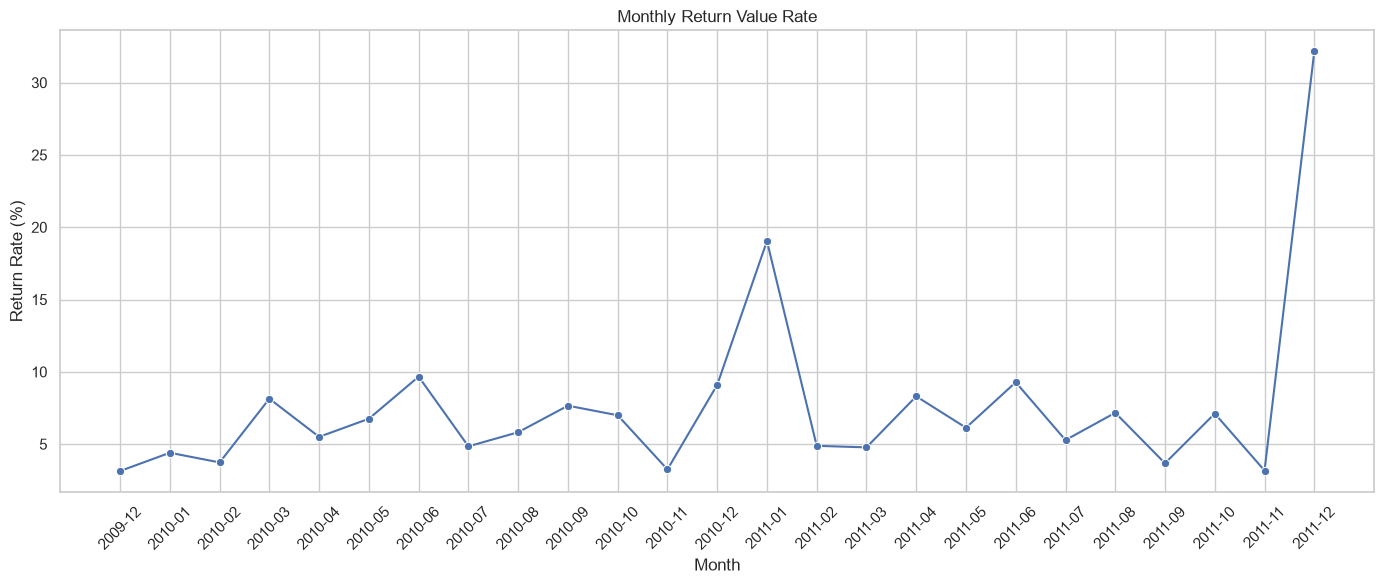

In [62]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    x=return_rate_monthly.index.astype(str),
    y=return_rate_monthly.values,
    marker="o"
)

plt.title("Monthly Return Value Rate")
plt.xlabel("Month")
plt.ylabel("Return Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [63]:
country_revenue.to_csv(
    REPORTS_DIR / "country_revenue.csv"
)

product_revenue.to_csv(
    REPORTS_DIR / "product_revenue.csv"
)

monthly_revenue.to_csv(
    REPORTS_DIR / "monthly_revenue.csv"
)

monthly_returns.to_csv(
    REPORTS_DIR / "monthly_returns.csv"
)

outlier_summary.to_csv(
    REPORTS_DIR / "outlier_comparison.csv",
    index=False
)

<h2>Save the Important Figures</h2>

In [64]:
plt.savefig(
    FIGURES_DIR / "monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

<h2>Create an EDA Summary Table</h2>

In [66]:
# Calculate return metrics locally in this notebook

total_return_value = returns_df["ReturnValue"].sum()

return_value_rate = (
    total_return_value / total_revenue * 100
)

eda_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Units",
        "Total Orders",
        "Unique Products",
        "Identified Customers",
        "Countries",
        "Average Order Value",
        "Return Transactions",
        "Returned Units",
        "Return Value",
        "Return Value Rate (%)"
    ],

    "Value": [
        total_revenue,
        total_units,
        total_orders,
        total_products,
        total_customers,
        total_countries,
        average_order_value,
        len(returns_df),
        returns_df["Quantity"].abs().sum(),
        total_return_value,
        return_value_rate
    ]
})

eda_summary

,Metric,Value
0,Total Revenue,"20,476,634.02"
1,Total Units,"11,455,908.00"
2,Total Orders,"41,942.00"
3,Unique Products,"4,984.00"
4,Identified Customers,"5,881.00"
5,Countries,43.00
6,Average Order Value,488.21
7,Return Transactions,"22,496.00"
8,Returned Units,"1,046,134.00"
9,Return Value,"1,462,424.18"
